<a href="https://colab.research.google.com/github/atanasovmi/Quantum-/blob/main/notebookA_encoding_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 1: Quantum Data Encoding - Visual Demo

"""
This notebook demonstrates three ways to encode classical data into quantum circuits with the goal to show students how classical information becomes quantum states
"""

# Quantum Data Encoding: From Classical to Quantum

**The Challenge**: Quantum computers work with qubits in superposition.
How do we feed classical data (images, numbers, text) into quantum circuits?

**The Solution**: Data encoding schemes!



In [ ]:
# !pip install qiskit qiskit-aer matplotlib numpy
!pip install qiskit qiskit-aer qiskit-machine-learning medmnist pylatexenc qiskit-optimization

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 647.4/647.4 kB 17.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 84.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 92.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 237.1/237.1 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 72.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 8.4 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=bc7e2925ff1f37f8

In [ ]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import ZFeatureMap, ZZFeatureMap
from qiskit.visualization import plot_bloch_multivector, plot_histogram
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt
import numpy as np



## Example 1: Basis Encoding (Digital Encoding)

**Idea**: Map classical bits directly to qubit states
- Bit 0 → |0⟩ state
- Bit 1 → |1⟩ state

**Example**: Encode the number 5 = 101 in binary



Encoding binary string: 101
Circuit:


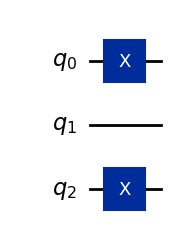


Quantum state: Statevector([0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j,
             0.+0.j],
            dims=(2, 2, 2))


In [ ]:
def basis_encoding_demo():
    """Encode binary string 101 (decimal 5) into 3 qubits"""

    # Create circuit with 3 qubits
    qc = QuantumCircuit(3)

    # Encode 101: qubit 0 = 1, qubit 1 = 0, qubit 2 = 1
    binary_string = "101"

    for i, bit in enumerate(binary_string):
        if bit == '1':
            qc.x(i)  # Apply X gate (bit flip) to encode 1

    # Visualize
    print("Encoding binary string: 101")
    print(f"Circuit:")
    display(qc.draw('mpl'))

    # Show the quantum state
    state = Statevector(qc)
    print(f"\nQuantum state: {state}")

    return qc

basis_circuit = basis_encoding_demo()



**Efficiency**: To encode n bits classically, we need n qubits
- Not very efficient! Same as classical
- But it's simple and intuitive



## Example 2: Amplitude Encoding (Efficient!)

**Idea**: Encode data as amplitudes of quantum state
- For n qubits, we can encode 2^n values!
- **4 values need only 2 qubits** (vs 4 classical bits)

**Example**: Encode vector [0.5, 0.3, 0.2, 0.0]



Classical data: [0.5, 0.3, 0.2, 0.0]
Normalized: [0.81110711 0.48666426 0.32444284 0.        ]

Using only 2 qubits to encode 4 values!

Circuit (decomposed):


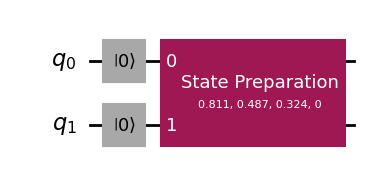


Quantum state amplitudes: [0.81110711+0.j 0.48666426+0.j 0.32444284+0.j 0.        +0.j]


In [ ]:
def amplitude_encoding_demo():
    """Encode 4 values using only 2 qubits"""

    # Classical data: 4 pixel values (normalized)
    data = np.array([0.5, 0.3, 0.2, 0.0])

    # Normalize to unit vector (quantum requirement)
    normalized_data = data / np.linalg.norm(data)

    # Create quantum state directly
    qc = QuantumCircuit(2)
    qc.initialize(normalized_data, [0, 1])

    print("Classical data: [0.5, 0.3, 0.2, 0.0]")
    print(f"Normalized: {normalized_data}")
    print(f"\nUsing only 2 qubits to encode 4 values!")
    print("\nCircuit (decomposed):")
    display(qc.decompose().draw('mpl'))

    # Show state vector
    state = Statevector(qc)
    print(f"\nQuantum state amplitudes: {state.data}")

    return qc

amplitude_circuit = amplitude_encoding_demo()



**Key Insight**:
- Classical: 4 values → 4 bits
- Quantum: 4 values → 2 qubits (exponential advantage!)
- This is why quantum computing can be powerful for large datasets



## Example 3: Angle Encoding (Feature Maps)

**Idea**: Encode data as rotation angles
- Each feature becomes a rotation parameter
- Creates entanglement for richer representations

**Example**: Encode two pixel values [0.2, 0.8]



Encoding pixel values: [0.2, 0.8]

ZFeatureMap circuit:


/tmp/ipython-input-2586153098.py:8: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._z_feature_map.ZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the z_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZFeatureMap(feature_dimension=2, reps=1)


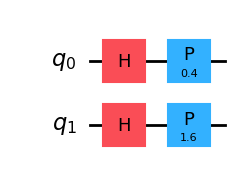


Bloch sphere representation:


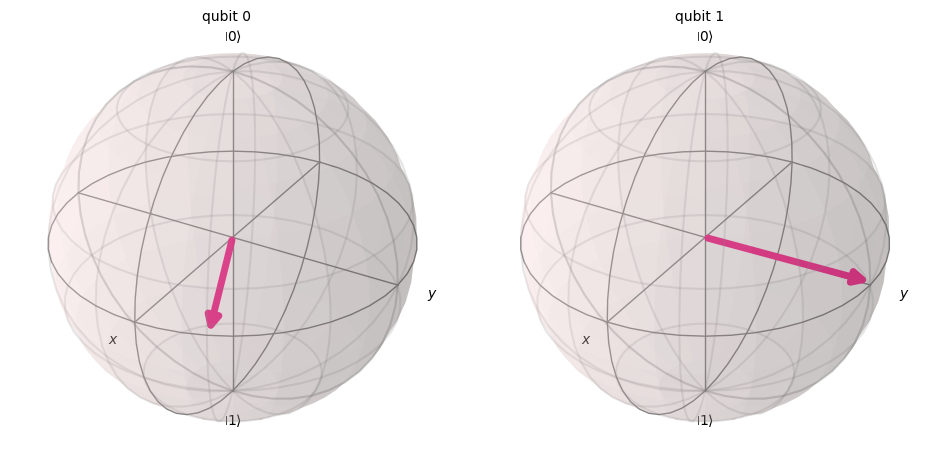

In [ ]:
def angle_encoding_demo():
    """Encode 2 features using ZFeatureMap - used in QML"""

    # Classical data: 2 pixel values
    data = [0.2, 0.8]

    # Create feature map (2 qubits for 2 features)
    feature_map = ZFeatureMap(feature_dimension=2, reps=1)

    # Bind the data
    qc = feature_map.assign_parameters(data)

    print(f"Encoding pixel values: {data}")
    print("\nZFeatureMap circuit:")
    display(qc.decompose().draw('mpl'))

    # Show the quantum state
    state = Statevector(qc)

    # Visualize on Bloch sphere
    print("\nBloch sphere representation:")
    display(plot_bloch_multivector(state))

    return qc

angle_circuit = angle_encoding_demo()



**How it works**:
1. H gate: Put qubit in superposition
2. P(2*x) gate: Rotate by angle proportional to data value
3. Creates smooth, continuous encoding



## Comparison: Same Data, Three Encodings

Let's encode the same 2-bit data [0, 1] three ways



/tmp/ipython-input-2350430267.py:23: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._z_feature_map.ZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the z_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZFeatureMap(2, reps=1)


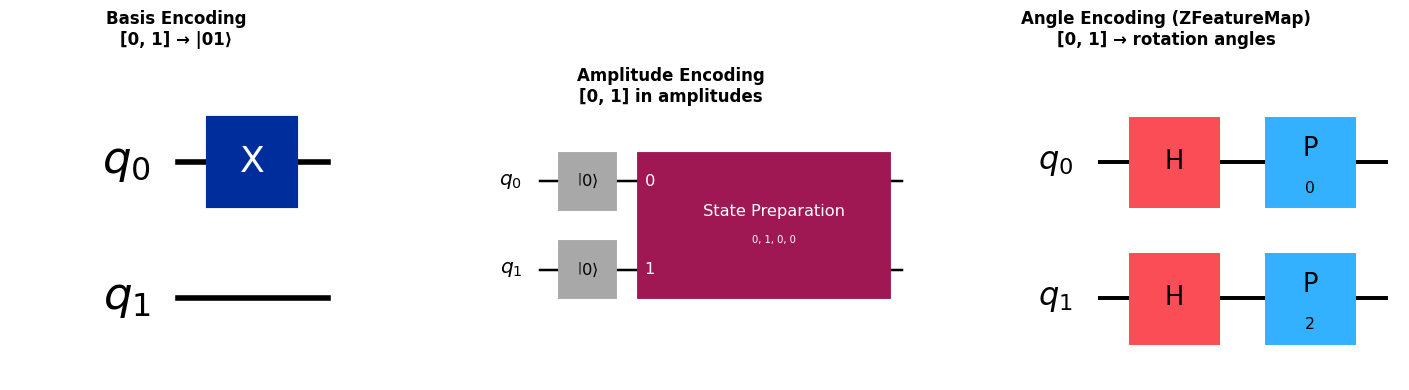

Same data [0, 1], three different quantum representations!


In [ ]:
def compare_encodings():
    """Compare three encoding methods for binary data [0, 1]"""

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # 1. Basis Encoding
    qc1 = QuantumCircuit(2)
    qc1.x(0)  # Second bit is 1
    qc1.draw('mpl', ax=axes[0])
    axes[0].set_title('Basis Encoding\n[0, 1] → |01⟩', fontweight='bold')

    # 2. Amplitude Encoding
    qc2 = QuantumCircuit(2)
    # Encode [0, 1] with padding as [0, 1, 0, 0]
    # This represents: no |00⟩, some |01⟩, more |10⟩, no |11⟩
    data_amp = np.array([0.0, 1.0, 0.0, 0.0])
    norm = np.linalg.norm(data_amp)
    qc2.initialize(data_amp / norm, [0, 1])
    qc2.decompose().draw('mpl', ax=axes[1])
    axes[1].set_title('Amplitude Encoding\n[0, 1] in amplitudes', fontweight='bold')

    # 3. Angle Encoding
    feature_map = ZFeatureMap(2, reps=1)
    qc3 = feature_map.assign_parameters([0, 1])
    qc3.decompose().draw('mpl', ax=axes[2])
    axes[2].set_title('Angle Encoding (ZFeatureMap)\n[0, 1] → rotation angles', fontweight='bold')

    plt.tight_layout()
    plt.show()

    print("Same data [0, 1], three different quantum representations!")


compare_encodings()

## Interactive: Try Your Own Data!

Change the values below and see how the encoding changes



First encoding:
Your data: [0.3 0.7]

Generated quantum circuit:


/tmp/ipython-input-1251066925.py:10: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._z_feature_map.ZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the z_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZFeatureMap(len(pixel_values), reps=1)


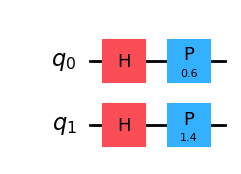


Quantum state vector (with phases):


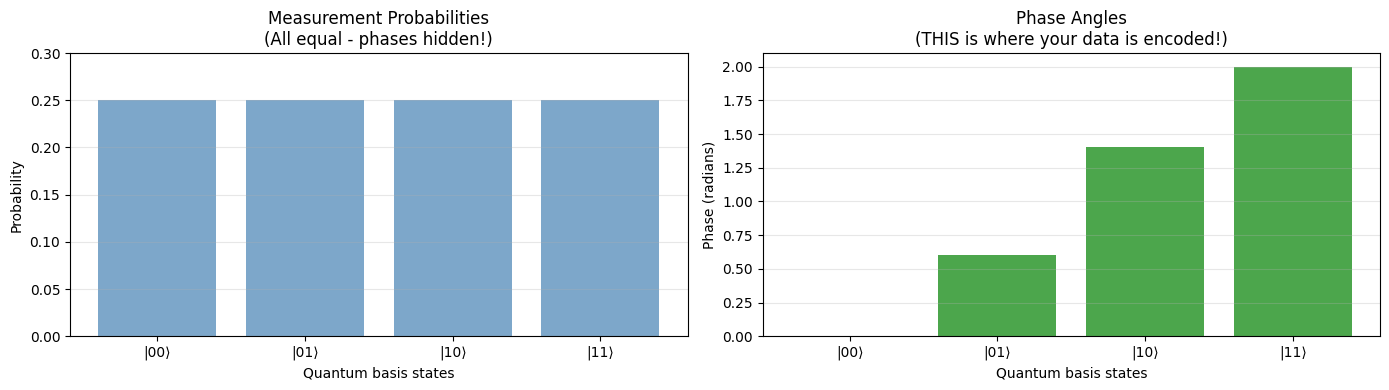


Detailed state vector:
|00⟩: 0.500 × e^(i×0.000) = 0.500∠0.0°
|01⟩: 0.500 × e^(i×0.600) = 0.500∠34.4°
|10⟩: 0.500 × e^(i×1.400) = 0.500∠80.2°
|11⟩: 0.500 × e^(i×2.000) = 0.500∠114.6°


Second encoding:
Your data: [0.3 0.1]

Generated quantum circuit:


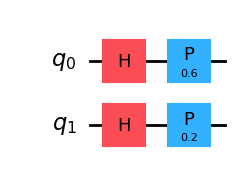


Quantum state vector (with phases):


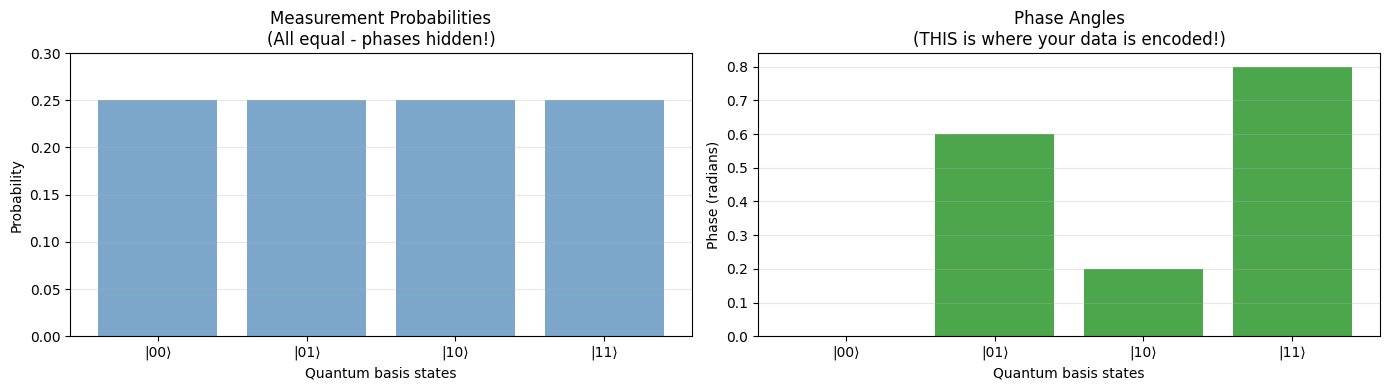


Detailed state vector:
|00⟩: 0.500 × e^(i×0.000) = 0.500∠0.0°
|01⟩: 0.500 × e^(i×0.600) = 0.500∠34.4°
|10⟩: 0.500 × e^(i×0.200) = 0.500∠11.5°
|11⟩: 0.500 × e^(i×0.800) = 0.500∠45.8°


In [ ]:
def interactive_encoding_with_interference(pixel_values):
    """
    Show how phase encoding affects interference
    """

    # Normalize to [0, 1] range
    pixel_values = np.clip(pixel_values, 0, 1)

    # Create feature map
    feature_map = ZFeatureMap(len(pixel_values), reps=1)
    qc = feature_map.assign_parameters(pixel_values)

    print(f"Your data: {pixel_values}")
    print("\nGenerated quantum circuit:")
    display(qc.decompose().draw('mpl'))

    # Show state vector with PHASES
    state = Statevector(qc)
    print("\nQuantum state vector (with phases):")

    # Create figure with 2 subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

    # Left: Probability distribution
    probs = np.abs(state.data)**2
    labels = [f'|{i:0{len(pixel_values)}b}⟩' for i in range(len(probs))]

    ax1.bar(labels, probs, color='steelblue', alpha=0.7)
    ax1.set_xlabel('Quantum basis states')
    ax1.set_ylabel('Probability')
    ax1.set_title('Measurement Probabilities\n(All equal - phases hidden!)')
    ax1.set_ylim([0, 0.3])
    ax1.grid(True, alpha=0.3, axis='y')

    # Right: Phase information (angle of complex number)
    phases = np.angle(state.data)  # Extract phase angles
    colors = ['red' if p < 0 else 'green' for p in phases]

    ax2.bar(labels, phases, color=colors, alpha=0.7)
    ax2.set_xlabel('Quantum basis states')
    ax2.set_ylabel('Phase (radians)')
    ax2.set_title('Phase Angles\n(THIS is where your data is encoded!)')
    ax2.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
    ax2.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

    # Print actual state with phases
    print("\nDetailed state vector:")
    for i, (amp, label) in enumerate(zip(state.data, labels)):
        magnitude = np.abs(amp)
        phase = np.angle(amp)
        print(f"{label}: {magnitude:.3f} × e^(i×{phase:.3f}) = {magnitude:.3f}∠{np.degrees(phase):.1f}°")

# Try different values and see how PHASES change!
print("First encoding:")
interactive_encoding_with_interference([0.3, 0.7])

print("\n" + "="*60 + "\n")

print("Second encoding:")
interactive_encoding_with_interference([0.3, 0.1])


## Key Takeaways

1. **Classical → Quantum is non-trivial**: Need encoding schemes

2. **Three main approaches**:
   - Basis: Simple but inefficient (1:1 mapping)
   - Amplitude: Efficient (exponential compression)
   - Angle: Suitable for ML (smooth, entangled)

3. **QML uses Angle Encoding** because:
   - Creates smooth feature space
   - Enables gradient-based learning
   - Leverages entanglement

4. **Business Implication**:
   - Data preprocessing is critical for QML
   - Not all classical ML techniques transfer directly
   - Need quantum-native algorithms



## Real-World Example: Encoding Handwritten Digits (0 vs 1)

**Business Context**: How does image encoding scale?
- Classical: 64 pixels → 64 bytes of memory
- Quantum: 64 pixels → 6 qubits (2^6 = 64 dimensions)

Let's see this with actual digit images!

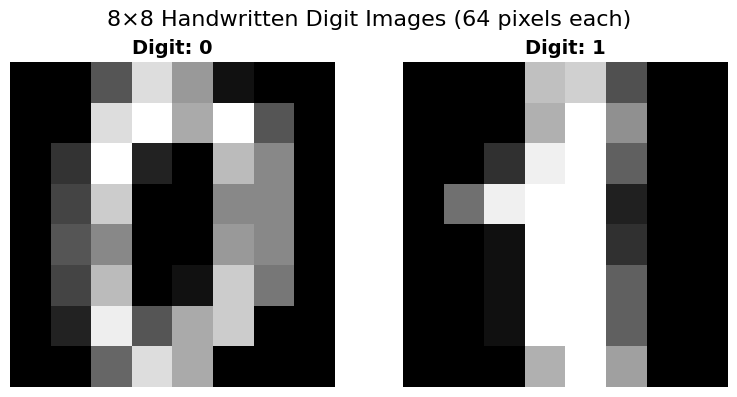

Image shape: (8, 8)
Flattened data: 64 pixels
Data range: [0.0, 15.0]


In [ ]:
from sklearn.datasets import load_digits
from sklearn.preprocessing import MinMaxScaler

# Load 8x8 digit images
digits = load_digits()

# Get one example of '0' and one example of '1'
zero_idx = np.where(digits.target == 0)[0][0]
one_idx = np.where(digits.target == 1)[0][0]

zero_image = digits.data[zero_idx]  # 64 pixels (8x8 flattened)
one_image = digits.data[one_idx]

# Normalize to [0, 1] range for quantum encoding
scaler = MinMaxScaler()
zero_normalized = scaler.fit_transform(zero_image.reshape(-1, 1)).flatten()
one_normalized = scaler.transform(one_image.reshape(-1, 1)).flatten()

# Visualize original images
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(digits.images[zero_idx], cmap='gray')
axes[0].set_title('Digit: 0', fontsize=14, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(digits.images[one_idx], cmap='gray')
axes[1].set_title('Digit: 1', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.suptitle('8×8 Handwritten Digit Images (64 pixels each)', fontsize=16)
plt.tight_layout()
plt.show()

print(f"Image shape: {digits.images[zero_idx].shape}")
print(f"Flattened data: {zero_image.shape[0]} pixels")
print(f"Data range: [{zero_image.min()}, {zero_image.max()}]")

### Classical vs Quantum Encoding Comparison

Let's compare how classical and quantum computers encode the same digit image

In [ ]:
def compare_classical_quantum_encoding(image_data, digit_label):
    """Compare classical and quantum encoding of a digit image"""

    print(f"\n{'='*60}")
    print(f"ENCODING DIGIT '{digit_label}' - CLASSICAL vs QUANTUM")
    print(f"{'='*60}\n")

    # CLASSICAL ENCODING
    print("📊 CLASSICAL ENCODING:")
    print(f"   • Storage: 64 pixels × 1 byte = 64 bytes")
    print(f"   • Representation: Direct 1:1 mapping")
    print(f"   • Memory required: 64 bytes")
    print(f"   • Scaling: Linear (N pixels = N bytes)")

    # Show classical data
    print(f"\n   First 10 pixel values: {image_data[:10]}")

    # QUANTUM ENCODING
    print(f"\n⚛️  QUANTUM ENCODING:")

    # Option 1: Full encoding (too many qubits for practical demo)
    full_qubits_needed = int(np.ceil(np.log2(len(image_data))))
    print(f"   • Amplitude Encoding: {full_qubits_needed} qubits")
    print(f"   • Can encode 2^{full_qubits_needed} = {2**full_qubits_needed} values")
    print(f"   • Exponential compression!")

    # Option 2: Reduced encoding (practical demo with 4 qubits)
    reduced_size = 64  # Use only 16 pixels for quantum demo
    reduced_data = image_data[:reduced_size]
    reduced_data_norm = reduced_data / np.linalg.norm(reduced_data)

    qubits_for_demo = int(np.ceil(np.log2(len(reduced_data))))

    print(f"\n   📌 Demo: {qubits_for_demo} qubits")
    print(f"   • Classical: 64 bytes")
    print(f"   • Quantum: 6 qubits (64 amplitude values)")
    print(f"   • Scaling: Logarithmic (N values = log₂(N) qubits)")

    # Create quantum circuit for reduced data
    qc = QuantumCircuit(qubits_for_demo)
    qc.initialize(reduced_data_norm, range(qubits_for_demo))

    return qc, reduced_data_norm

# Compare for digit '0'
qc_zero, data_zero = compare_classical_quantum_encoding(zero_normalized, '0')


ENCODING DIGIT '0' - CLASSICAL vs QUANTUM

📊 CLASSICAL ENCODING:
   • Storage: 64 pixels × 1 byte = 64 bytes
   • Representation: Direct 1:1 mapping
   • Memory required: 64 bytes
   • Scaling: Linear (N pixels = N bytes)

   First 10 pixel values: [0.         0.         0.33333333 0.86666667 0.6        0.06666667
 0.         0.         0.         0.        ]

⚛️  QUANTUM ENCODING:
   • Amplitude Encoding: 6 qubits
   • Can encode 2^6 = 64 values
   • Exponential compression!

   📌 Demo: 6 qubits
   • Classical: 64 bytes
   • Quantum: 6 qubits (64 amplitude values)
   • Scaling: Logarithmic (N values = log₂(N) qubits)


### Visualize Quantum Circuit for Digit '0'

This circuit shows how we encode the first 16 pixels using only 4 qubits


QUANTUM CIRCUIT FOR ENCODING DIGIT '0'


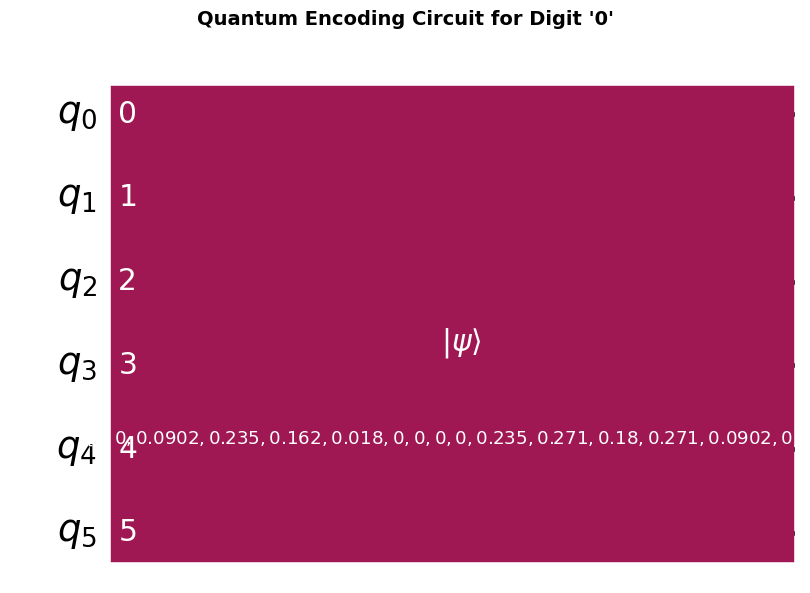


💡 Key Insight:
   This complex circuit encodes 64 pixel values
   Using only 6 qubits in quantum superposition!


In [ ]:
print("\n" + "="*60)
print("QUANTUM CIRCUIT FOR ENCODING DIGIT '0'")
print("="*60)

# Show the circuit (without full decomposition for better visualization)
fig, ax = plt.subplots(figsize=(14, 6))
qc_zero.draw('mpl', ax=ax, fold=-1)
plt.suptitle("Quantum Encoding Circuit for Digit '0'",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 Key Insight:")
print("   This complex circuit encodes 64 pixel values")
print("   Using only 6 qubits in quantum superposition!")

### Quantum State Amplitudes

Let's visualize how the classical pixel values are encoded as quantum amplitudes


QUANTUM STATE AMPLITUDES


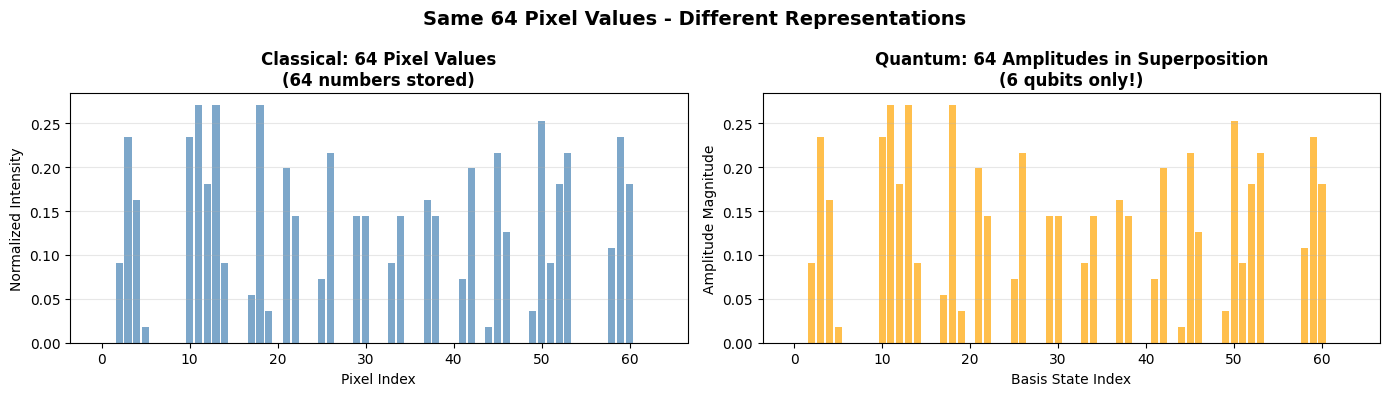


✓ Same information, fundamentally different encoding!


In [ ]:
print("\n" + "="*60)
print("QUANTUM STATE AMPLITUDES")
print("="*60)

# Get quantum state
state_zero = Statevector(qc_zero)
amplitudes = state_zero.data

# Plot amplitudes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Classical pixel values
ax1.bar(range(len(data_zero)), data_zero, color='steelblue', alpha=0.7)
ax1.set_xlabel('Pixel Index')
ax1.set_ylabel('Normalized Intensity')
ax1.set_title("Classical: 64 Pixel Values\n(64 numbers stored)", fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

# Quantum amplitudes
ax2.bar(range(len(amplitudes)), np.abs(amplitudes), color='orange', alpha=0.7)
ax2.set_xlabel('Basis State Index')
ax2.set_ylabel('Amplitude Magnitude')
ax2.set_title("Quantum: 64 Amplitudes in Superposition\n(6 qubits only!)", fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.suptitle("Same 64 Pixel Values - Different Representations",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✓ Same information, fundamentally different encoding!")

### Full Comparison: Digit 0 vs Digit 1

Let's see how both digits are encoded side-by-side

In [ ]:
print("\n" + "="*60)
print("SIDE-BY-SIDE: ENCODING '0' vs '1'")
print("="*60)

# Encode digit '1'
qc_one, data_one = compare_classical_quantum_encoding(one_normalized, '1')

# Create comparison visualization
fig = plt.figure(figsize=(16, 8))
gs = fig.add_gridspec(3, 4, hspace=0.4, wspace=0.3)

# Row 1: Original images
ax1 = fig.add_subplot(gs[0, 0:2])
ax1.imshow(digits.images[zero_idx], cmap='gray')
ax1.set_title("Digit '0' (8×8 = 64 pixels)", fontsize=12, fontweight='bold')
ax1.axis('off')

ax2 = fig.add_subplot(gs[0, 2:4])
ax2.imshow(digits.images[one_idx], cmap='gray')
ax2.set_title("Digit '1' (8×8 = 64 pixels)", fontsize=12, fontweight='bold')
ax2.axis('off')

# Row 2: Classical encoding
ax3 = fig.add_subplot(gs[1, 0:2])
ax3.bar(range(64), zero_normalized[:64], color='steelblue', alpha=0.7)
ax3.set_title("Classical: 64 bytes\n(1:1 mapping)", fontsize=10, fontweight='bold')
ax3.set_ylabel('Pixel Value')
ax3.grid(True, alpha=0.3, axis='y')

ax4 = fig.add_subplot(gs[1, 2:4])
ax4.bar(range(64), one_normalized[:64], color='steelblue', alpha=0.7)
ax4.set_title("Classical: 64 bytes\n(1:1 mapping)", fontsize=10, fontweight='bold')
ax4.set_ylabel('Pixel Value')
ax4.grid(True, alpha=0.3, axis='y')

# Row 3: Quantum encoding (amplitudes)
state_one = Statevector(qc_one)

ax5 = fig.add_subplot(gs[2, 0:2])
ax5.bar(range(64), np.abs(state_zero.data), color='orange', alpha=0.7)
ax5.set_title("Quantum: 6 qubits\n(exponential compression)", fontsize=10, fontweight='bold')
ax5.set_ylabel('Amplitude')
ax5.set_xlabel('Basis State')
ax5.grid(True, alpha=0.3, axis='y')

ax6 = fig.add_subplot(gs[2, 2:4])
ax6.bar(range(64), np.abs(state_one.data), color='orange', alpha=0.7)
ax6.set_title("Quantum: 6 qubits\n(exponential compression)", fontsize=10, fontweight='bold')
ax6.set_ylabel('Amplitude')
ax6.set_xlabel('Basis State')
ax6.grid(True, alpha=0.3, axis='y')

plt.suptitle("Classical vs Quantum Image Encoding: '0' and '1'",
             fontsize=16, fontweight='bold')
plt.show()

### Scaling Analysis: Memory Requirements

How does the compression advantage grow with larger images?

In [ ]:
print("\n" + "="*60)
print("SCALING ANALYSIS: Memory Requirements")
print("="*60)

# Calculate scaling
image_sizes = [4, 16, 64, 256, 1024, 4096]  # pixel counts
classical_memory = image_sizes  # bytes (1:1)
quantum_qubits = [int(np.ceil(np.log2(size))) for size in image_sizes]

# Create scaling comparison table
print(f"\n{'Image Size':<15} {'Classical (bytes)':<20} {'Quantum (qubits)':<20} {'Compression Factor':<20}")
print("-" * 75)
for i, size in enumerate(image_sizes):
    compression = size / quantum_qubits[i] if quantum_qubits[i] > 0 else 0
    print(f"{size:<15} {classical_memory[i]:<20} {quantum_qubits[i]:<20} {compression:.1f}x")

# Visualize scaling
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Linear vs Logarithmic scaling
ax1.plot(image_sizes, classical_memory, 'o-', label='Classical (Linear)',
         linewidth=2, markersize=8, color='steelblue')
ax1.plot(image_sizes, quantum_qubits, 's-', label='Quantum (Logarithmic)',
         linewidth=2, markersize=8, color='orange')
ax1.set_xlabel('Number of Pixels', fontsize=12)
ax1.set_ylabel('Storage Required', fontsize=12)
ax1.set_title('Memory Scaling: Classical vs Quantum', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_xscale('log')
ax1.set_yscale('log')

# Compression factor
compression_factors = [classical_memory[i] / quantum_qubits[i]
                       for i in range(len(image_sizes))]
ax2.bar(range(len(image_sizes)), compression_factors,
        color='green', alpha=0.7, edgecolor='black')
ax2.set_xlabel('Image Size (pixels)', fontsize=12)
ax2.set_ylabel('Compression Factor (x)', fontsize=12)
ax2.set_title('Quantum Compression Advantage', fontsize=14, fontweight='bold')
ax2.set_xticks(range(len(image_sizes)))
ax2.set_xticklabels(image_sizes, rotation=45)
ax2.grid(True, alpha=0.3, axis='y')

# Add values on bars
for i, v in enumerate(compression_factors):
    ax2.text(i, v + 5, f'{v:.0f}x', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n💡 KEY BUSINESS INSIGHT:")
print("   • For 4096-pixel image: Classical needs 4096 bytes")
print("   • Quantum needs only 12 qubits!")
print("   • 341x compression factor")
print("   • This exponential advantage is why tech giants invest billions")

---

## Summary

**You've learned**:
- How classical data becomes quantum states
- Three encoding methods with trade-offs
- The exponential dimensionality of quantum feature spaces

**Next**: See these encodings in action for real classification!
(Proceed to Notebook B: Classification Demo)

